CPU UTILISATION PROOF — BlockParallelGBM
Available logical CPU cores: 4


TRAINING SEQUENTIAL BASELINE (B=1)

SEQUENTIAL BASELINE (B=1)
Tree  1 | PID=315 | time=6.667s
Tree  2 | PID=315 | time=6.682s
Tree  3 | PID=315 | time=6.592s
Tree  4 | PID=315 | time=6.616s
Tree  5 | PID=315 | time=6.564s
Tree  6 | PID=315 | time=6.535s
Tree  7 | PID=315 | time=6.559s
Tree  8 | PID=315 | time=6.580s
Tree  9 | PID=315 | time=6.591s
Tree 10 | PID=315 | time=6.600s
Tree 11 | PID=315 | time=6.606s
Tree 12 | PID=315 | time=6.975s
Tree 13 | PID=315 | time=6.574s
Tree 14 | PID=315 | time=6.623s
Tree 15 | PID=315 | time=6.514s
Tree 16 | PID=315 | time=6.665s

Summary
Total tree fits: 16
Unique PIDs:     1
PIDs observed:   [315]

SEQUENTIAL RESOURCE USAGE
Samples collected: 213

CPU Usage
Mean CPU Usage : 101.7%
Peak CPU Usage : 187.2%

Top Active Processes
pid
315    100.157277
331     50.733333
12       2.024390
Name: cpu, dtype: float64

Wall-clock time: 106.446s


TRAINING BLOCK PARALLEL (B=2)

BLOCK-

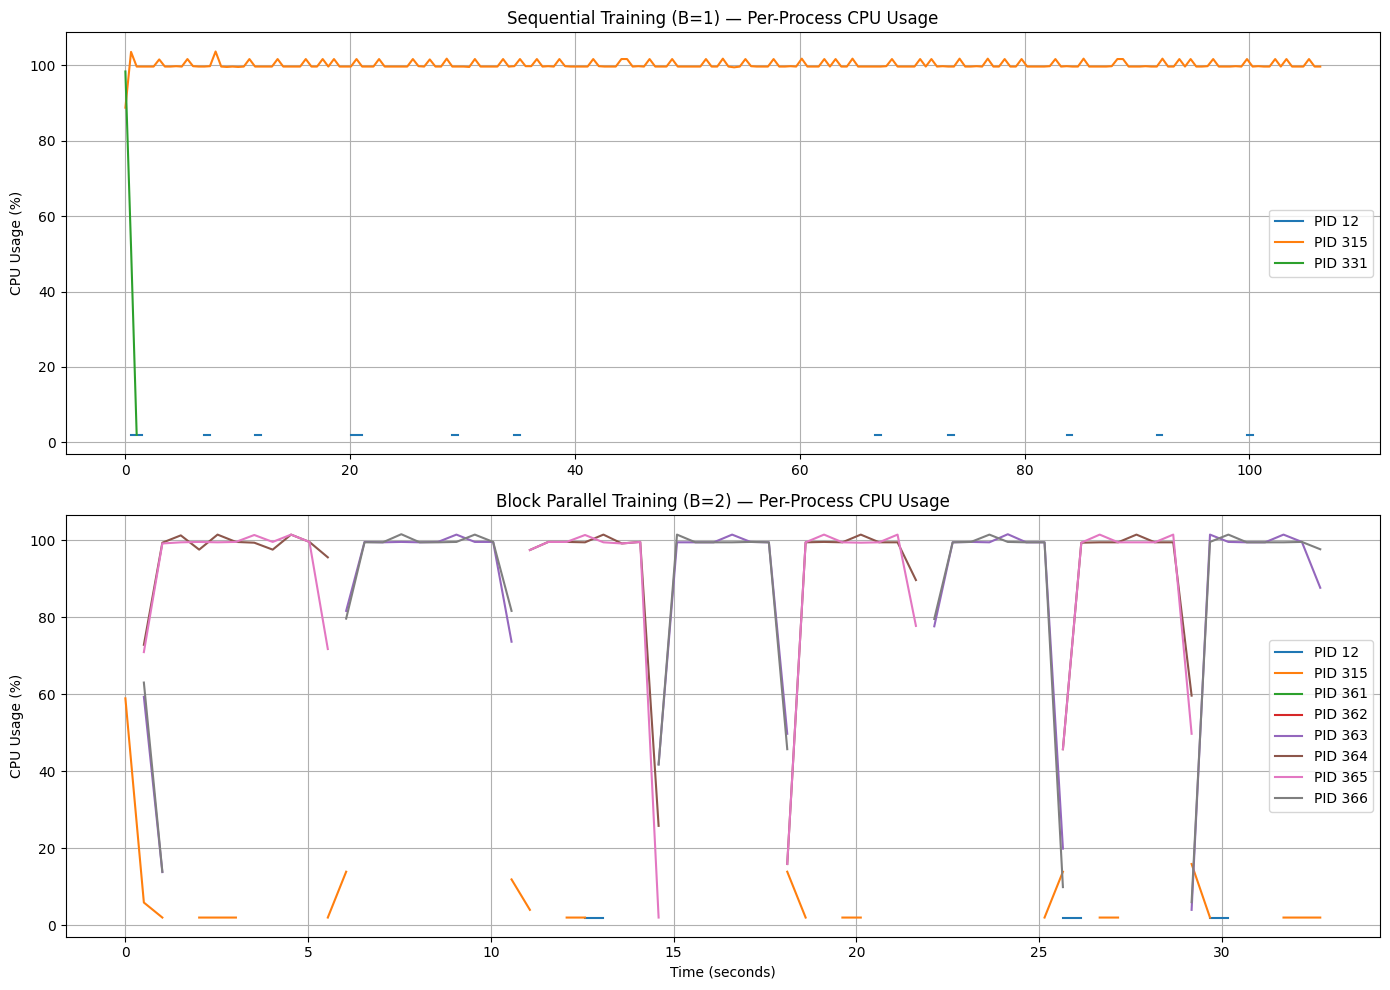


Saved: /kaggle/working/per_process_comparison.png


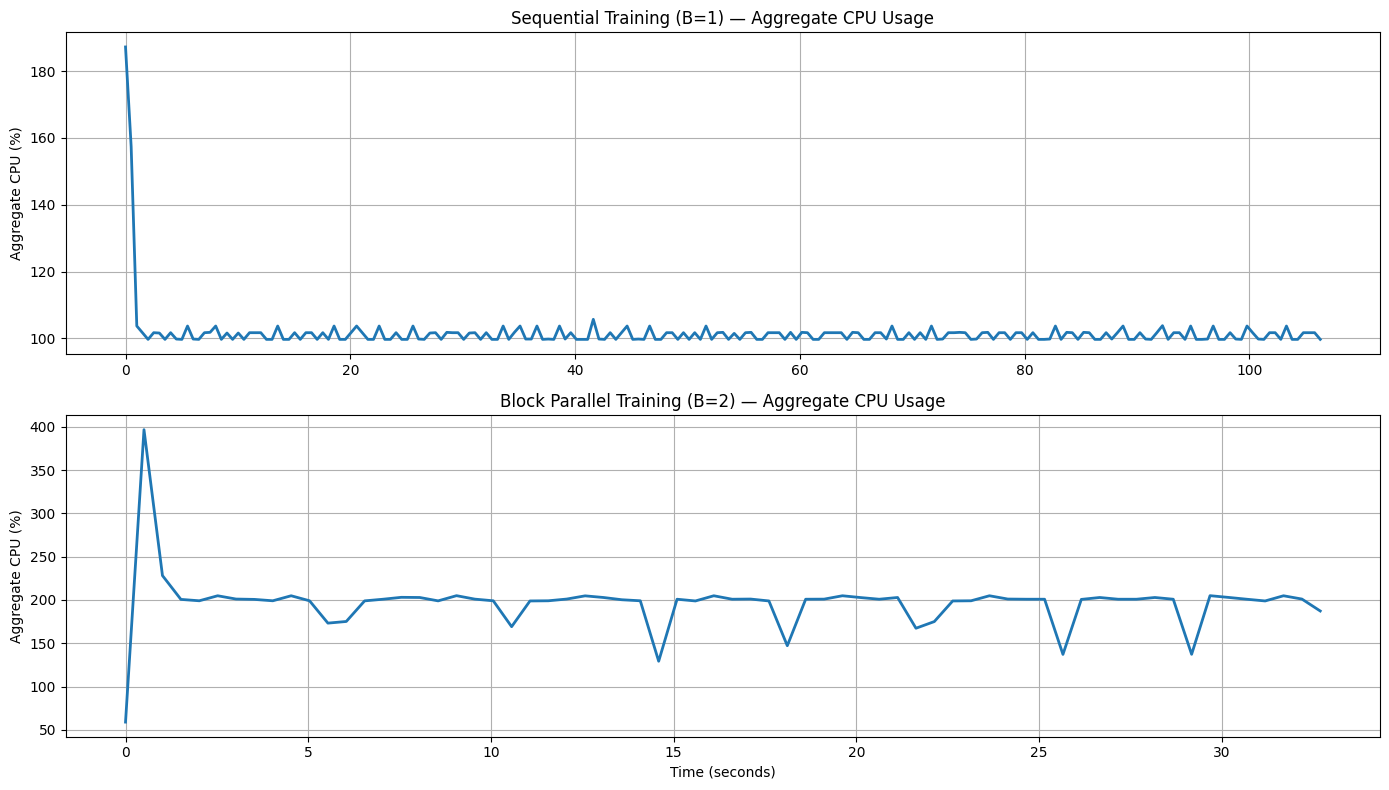


Saved: /kaggle/working/aggregate_cpu_comparison.png

GENERATED FILES
1. per_process_comparison.png
2. aggregate_cpu_comparison.png


In [1]:
"""
CPU utilisation proof using the ACTUAL BlockParallelGBM implementation.

Enhanced version with:
- Dynamic CPU monitoring
- Per-process CPU logging
- RAM monitoring
- Worker PID tracking
- Combined comparison plots
- 300 DPI PNG export
- Kaggle-ready

Generated files:
1. per_process_comparison.png
2. aggregate_cpu_comparison.png
"""

# ============================================================
# IMPORTS
# ============================================================

import os
import sys
import time
import threading

import psutil
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor

# ============================================================
# IMPORT YOUR MODEL
# ============================================================

sys.path.append("/kaggle/input/datasets/baibhavkundu/blockpgbm")

from block_parallel_gbm_kaggle import BlockParallelGBM

# ============================================================
# LOG FILES
# ============================================================

WORKER_LOG = "/kaggle/working/worker_log.txt"

RESOURCE_LOG_SEQ = "/kaggle/working/resource_seq.csv"
RESOURCE_LOG_PAR = "/kaggle/working/resource_par.csv"

open(WORKER_LOG, "w").close()

# ============================================================
# MONKEY PATCH TREE FIT
# ============================================================

_original_fit = DecisionTreeRegressor.fit

def patched_fit(self, X, y, *args, **kwargs):

    pid = os.getpid()

    t0 = time.perf_counter()

    result = _original_fit(self, X, y, *args, **kwargs)

    elapsed = time.perf_counter() - t0

    with open(WORKER_LOG, "a") as f:
        f.write(f"{pid},{round(elapsed,3)}\n")

    return result

DecisionTreeRegressor.fit = patched_fit

# ============================================================
# DATASET
# ============================================================

X, y = make_classification(
    n_samples=50000,
    n_features=200,
    n_informative=50,
    random_state=42
)

X_tr, X_val, y_tr, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("=" * 70)
print("CPU UTILISATION PROOF — BlockParallelGBM")
print("=" * 70)

print(f"Available logical CPU cores: {os.cpu_count()}")

# ============================================================
# RESOURCE MONITOR
# ============================================================

monitoring = False

def monitor_resources(log_file, interval=0.5):

    """
    Logs:
    - timestamp
    - pid
    - cpu %
    - ram %
    """

    # Prime CPU measurements
    for proc in psutil.process_iter():
        try:
            proc.cpu_percent(None)
        except:
            pass

    time.sleep(0.1)

    while monitoring:

        timestamp = time.perf_counter()

        rows = []

        for proc in psutil.process_iter(['pid', 'name']):

            try:

                cpu = proc.cpu_percent(None)

                if cpu > 0:

                    ram = proc.memory_percent()

                    rows.append(
                        f"{timestamp},{proc.pid},{cpu},{ram}\n"
                    )

            except:
                pass

        with open(log_file, "a") as f:
            f.writelines(rows)

        time.sleep(interval)

# ============================================================
# HELPER FUNCTIONS
# ============================================================

def summarize_worker_logs(title):

    print("\n" + "=" * 70)
    print(title)
    print("=" * 70)

    with open(WORKER_LOG, "r") as f:
        lines = f.readlines()

    records = []

    for line in lines:

        pid, elapsed = line.strip().split(",")

        records.append({
            "pid": int(pid),
            "time": float(elapsed)
        })

    for i, r in enumerate(records[:16]):

        print(
            f"Tree {i+1:2d} | "
            f"PID={r['pid']} | "
            f"time={r['time']:.3f}s"
        )

    pids = [r["pid"] for r in records]

    print("\nSummary")
    print(f"Total tree fits: {len(records)}")
    print(f"Unique PIDs:     {len(set(pids))}")
    print(f"PIDs observed:   {sorted(set(pids))}")

def summarize_resource_usage(log_file, title):

    df = pd.read_csv(
        log_file,
        names=["time", "pid", "cpu", "ram"]
    )

    print("\n" + "=" * 70)
    print(title)
    print("=" * 70)

    if len(df) == 0:
        print("No resource records found.")
        return

    grouped = df.groupby("time")["cpu"].sum()

    print(f"Samples collected: {len(grouped)}")

    print("\nCPU Usage")
    print(f"Mean CPU Usage : {grouped.mean():.1f}%")
    print(f"Peak CPU Usage : {grouped.max():.1f}%")

    print("\nTop Active Processes")

    top_procs = (
        df.groupby("pid")["cpu"]
        .mean()
        .sort_values(ascending=False)
        .head(10)
    )

    print(top_procs)

# ============================================================
# TRAINING FUNCTION
# ============================================================

def run_experiment(model, resource_log, title):

    global monitoring

    open(WORKER_LOG, "w").close()
    open(resource_log, "w").close()

    print("\n")
    print("=" * 70)
    print(title)
    print("=" * 70)

    monitoring = True

    monitor_thread = threading.Thread(
        target=monitor_resources,
        args=(resource_log,),
        daemon=True
    )

    monitor_thread.start()

    t0 = time.perf_counter()

    model.fit(
        X_tr,
        y_tr,
        X_val,
        y_val
    )

    elapsed = time.perf_counter() - t0

    monitoring = False

    monitor_thread.join(timeout=1)

    return elapsed

# ============================================================
# SEQUENTIAL BASELINE
# ============================================================

baseline = BlockParallelGBM(
    n_estimators=16,
    block_size=1,
    colsample=1.0,
    auto_scale_lr=False,
    n_jobs=1,
    random_state=42,
    verbose=False
)

seq_time = run_experiment(
    baseline,
    RESOURCE_LOG_SEQ,
    "TRAINING SEQUENTIAL BASELINE (B=1)"
)

summarize_worker_logs(
    "SEQUENTIAL BASELINE (B=1)"
)

summarize_resource_usage(
    RESOURCE_LOG_SEQ,
    "SEQUENTIAL RESOURCE USAGE"
)

print(f"\nWall-clock time: {seq_time:.3f}s")

# ============================================================
# BLOCK PARALLEL
# ============================================================

parallel_model = BlockParallelGBM(
    n_estimators=16,
    block_size=2,
    colsample=0.5,
    auto_scale_lr=True,
    n_jobs=-1,
    random_state=42,
    verbose=False
)

par_time = run_experiment(
    parallel_model,
    RESOURCE_LOG_PAR,
    "TRAINING BLOCK PARALLEL (B=2)"
)

summarize_worker_logs(
    "BLOCK-PARALLEL (B=2)"
)

summarize_resource_usage(
    RESOURCE_LOG_PAR,
    "BLOCK-PARALLEL RESOURCE USAGE"
)

print(f"\nWall-clock time: {par_time:.3f}s")

# ============================================================
# FINAL COMPARISON
# ============================================================

print("\n" + "=" * 70)
print("COMPARISON")
print("=" * 70)

print(f"Sequential time:     {seq_time:.3f}s")
print(f"Block-parallel time: {par_time:.3f}s")

print(f"\nSpeedup: {seq_time / par_time:.2f}x")

print("\nInterpretation:")
print("- B=1 should show ~100% aggregate CPU")
print("- B=2 should show ~200% aggregate CPU")
print("- Multiple PIDs confirm multiprocessing")
print("- Reduced wall-clock time confirms overlap")

# ============================================================
# LOAD RESOURCE LOGS
# ============================================================

seq_df = pd.read_csv(
    RESOURCE_LOG_SEQ,
    names=["time", "pid", "cpu", "ram"]
)

par_df = pd.read_csv(
    RESOURCE_LOG_PAR,
    names=["time", "pid", "cpu", "ram"]
)

# Normalize time axes
seq_df["time"] = seq_df["time"] - seq_df["time"].min()
par_df["time"] = par_df["time"] - par_df["time"].min()

# ============================================================
# COMBINED PER-PROCESS CPU PLOTS
# ============================================================

fig, axes = plt.subplots(
    2,
    1,
    figsize=(14, 10),
    sharex=False
)

# ------------------------
# Sequential
# ------------------------

seq_pivot = seq_df.pivot_table(
    index="time",
    columns="pid",
    values="cpu",
    aggfunc="mean"
)

for col in seq_pivot.columns:

    axes[0].plot(
        seq_pivot.index,
        seq_pivot[col],
        label=f"PID {col}"
    )

axes[0].set_title(
    "Sequential Training (B=1) — Per-Process CPU Usage"
)

axes[0].set_ylabel("CPU Usage (%)")

axes[0].grid(True)

axes[0].legend()

# ------------------------
# Parallel
# ------------------------

par_pivot = par_df.pivot_table(
    index="time",
    columns="pid",
    values="cpu",
    aggfunc="mean"
)

for col in par_pivot.columns:

    axes[1].plot(
        par_pivot.index,
        par_pivot[col],
        label=f"PID {col}"
    )

axes[1].set_title(
    "Block Parallel Training (B=2) — Per-Process CPU Usage"
)

axes[1].set_xlabel("Time (seconds)")

axes[1].set_ylabel("CPU Usage (%)")

axes[1].grid(True)

axes[1].legend()

plt.tight_layout()

PER_PROCESS_PATH = (
    "/kaggle/working/per_process_comparison.png"
)

plt.savefig(
    PER_PROCESS_PATH,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"\nSaved: {PER_PROCESS_PATH}")

# ============================================================
# COMBINED AGGREGATE CPU PLOTS
# ============================================================

fig, axes = plt.subplots(
    2,
    1,
    figsize=(14, 8),
    sharex=False
)

# ------------------------
# Sequential Aggregate
# ------------------------

seq_total = (
    seq_df.groupby("time")["cpu"]
    .sum()
    .reset_index()
)

axes[0].plot(
    seq_total["time"],
    seq_total["cpu"],
    linewidth=2
)

axes[0].set_title(
    "Sequential Training (B=1) — Aggregate CPU Usage"
)

axes[0].set_ylabel("Aggregate CPU (%)")

axes[0].grid(True)

# ------------------------
# Parallel Aggregate
# ------------------------

par_total = (
    par_df.groupby("time")["cpu"]
    .sum()
    .reset_index()
)

axes[1].plot(
    par_total["time"],
    par_total["cpu"],
    linewidth=2
)

axes[1].set_title(
    "Block Parallel Training (B=2) — Aggregate CPU Usage"
)

axes[1].set_xlabel("Time (seconds)")

axes[1].set_ylabel("Aggregate CPU (%)")

axes[1].grid(True)

plt.tight_layout()

AGGREGATE_PATH = (
    "/kaggle/working/aggregate_cpu_comparison.png"
)

plt.savefig(
    AGGREGATE_PATH,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"\nSaved: {AGGREGATE_PATH}")

# ============================================================
# OUTPUT FILES
# ============================================================

print("\n" + "=" * 70)
print("GENERATED FILES")
print("=" * 70)

print("1. per_process_comparison.png")
print("2. aggregate_cpu_comparison.png")